Successfully located data at: /Users/Diane/Desktop/PSYCH 186B/psych186b-project/audience-reviews-imdb

--- GROUND TRUTH SUMMARY ---
Total Movies: 46 | Total Reviews: 2300
Movies: {'Flop': 25, 'Hit': 21}


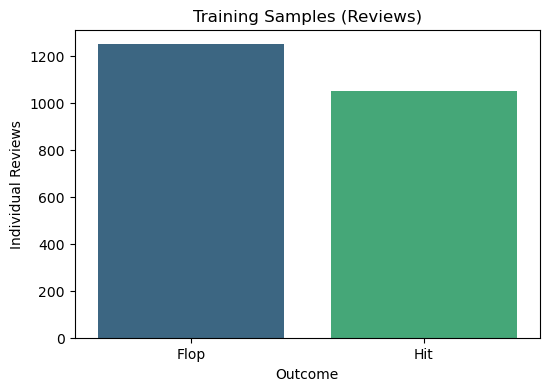


Starting Training...
Epoch 1 | Loss: 0.6805 | Acc: 0.5763


KeyboardInterrupt: 

In [3]:
import os, re, json, pickle, torch
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress minor warnings for cleaner output
warnings.filterwarnings("ignore", category=FutureWarning)

# ══════════════════════════════════════════════════════════════════════════════
# PREPROCESSING HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def clean_curr(v):
    if pd.isna(v) or v == "N/A": return np.nan
    s = re.sub(r'[^\d.]', '', str(v))
    return float(s) if s else np.nan

def parse_m_name(f):
    n = os.path.splitext(f)[0].lower()
    for p in ["imdb", "rt", "rottentomatoes", "reviews"]: n = n.replace(p, "")
    return n.strip("_")

def parse_rating(v):
    if pd.isna(v): return np.nan
    s = str(v).strip()
    if '%' in s: return float(s.replace('%','')) / 10.0
    if '/' in s:
        parts = s.split('/')
        return (float(parts[0])/float(parts[1]))*10.0 if float(parts[1]) != 0 else np.nan
    try: return float(s)
    except: return np.nan

def load_data(path):
    meta = pd.read_csv(os.path.join(path, "movie_metadata.csv"))
    
    # --- ADD THIS LINE TO FIX THE ERROR ---
    meta = meta.drop_duplicates(subset=['movie_key'], keep='last')
    # ---------------------------------------
    
    lookup = meta.set_index('movie_key')[['budget', 'gross_us', 'imdb_rating', 'year']].to_dict('index')
    all_dfs = []
    dropped_count = 0
    
    # The rest of your function remains the same...
    for f in [f for f in os.listdir(path) if f.endswith(".csv") and "metadata" not in f]:
        df = pd.read_csv(os.path.join(path, f))
        key = parse_m_name(f)
        m_data = lookup.get(key, {})
        
        b, g = clean_curr(m_data.get("budget")), clean_curr(m_data.get("gross_us"))
        if pd.isna(b) or pd.isna(g):
            dropped_count += 1
            continue

        df["budget"], df["gross"] = b, g
        df["imdb_rating"] = pd.to_numeric(m_data.get("imdb_rating"), errors='coerce')
        df["year"] = pd.to_numeric(m_data.get("year"), errors='coerce')
        df["movie_title"] = key
        if "user_rating" in df.columns: df["user_rating"] = df["user_rating"].apply(parse_rating)
        all_dfs.append(df)
        
    full_df = pd.concat(all_dfs, ignore_index=True)
    full_df["label"] = full_df.apply(lambda r: 1 if (r['gross']/r['budget']) >= 3.0 else 0, axis=1)
    return full_df.dropna(subset=["review_text"]).rename(columns={"user_rating": "avg_user_rating"}), dropped_count

# ══════════════════════════════════════════════════════════════════════════════
# BERT CLASSES
# ══════════════════════════════════════════════════════════════════════════════

class MovieDataset(Dataset):
    def __init__(self, texts, numeric, labels, tok):
        self.texts, self.numeric, self.labels, self.tok = texts, torch.tensor(numeric, dtype=torch.float32), torch.tensor(labels, dtype=torch.float32), tok
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        e = self.tok(self.texts[i], max_length=256, truncation=True, padding="max_length", return_tensors="pt")
        return {"ids": e["input_ids"].squeeze(0), "mask": e["attention_mask"].squeeze(0), "num": self.numeric[i], "lab": self.labels[i]}

class MovieClassifier(nn.Module):
    def __init__(self, n_dim):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        for n, p in self.bert.named_parameters():
            if "encoder.layer.11" not in n: p.requires_grad = False
        self.num_bnch = nn.Sequential(nn.Linear(n_dim, 64), nn.ReLU())
        self.fusion = nn.Sequential(nn.Linear(768+64, 256), nn.ReLU(), nn.Linear(256, 1))
    def forward(self, ids, mask, num):
        t_f = self.bert(ids, mask).last_hidden_state[:, 0, :]
        n_f = self.num_bnch(num)
        return self.fusion(torch.cat([t_f, n_f], dim=1)).squeeze(1)

# ══════════════════════════════════════════════════════════════════════════════
# MAIN ENGINE
# ══════════════════════════════════════════════════════════════════════════════

def main(path):
    df, dropped = load_data(path)
    
    label_counts = df["label"].value_counts().rename({0: "Flop", 1: "Hit"})
    movie_counts = df.groupby("movie_title")["label"].first().value_counts().rename({0: "Flop", 1: "Hit"})

    print("\n--- GROUND TRUTH SUMMARY ---")
    print(f"Total Movies: {df['movie_title'].nunique()} | Total Reviews: {len(df)}")
    print(f"Movies: {movie_counts.to_dict()}")

    plt.figure(figsize=(6, 4))
    sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index, legend=False, palette="viridis")
    plt.title("Training Samples (Reviews)"); plt.ylabel("Individual Reviews"); plt.xlabel("Outcome"); plt.show() 

    # Split
    gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, test_idx = next(gss.split(df, groups=df['movie_title']))
    train_df, test_df = df.iloc[train_idx], df.iloc[test_idx]

    feats = ["avg_user_rating", "imdb_rating", "year"]
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[feats].fillna(0))
    X_test = scaler.transform(test_df[feats].fillna(0))

    # Training
    tok = BertTokenizer.from_pretrained("bert-base-uncased")
    train_ldr = DataLoader(MovieDataset(train_df["review_text"].tolist(), X_train, train_df["label"].tolist(), tok), batch_size=16, shuffle=True)
    test_ldr = DataLoader(MovieDataset(test_df["review_text"].tolist(), X_test, test_df["label"].tolist(), tok), batch_size=16)

    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MovieClassifier(len(feats)).to(dev)
    opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)
    crit = nn.BCEWithLogitsLoss()

    print("\nStarting Training...")
    for ep in range(5):
        model.train()
        t_loss, t_acc, t_count = 0, 0, 0
        for b in train_ldr:
            opt.zero_grad()
            out = model(b["ids"].to(dev), b["mask"].to(dev), b["num"].to(dev))
            loss = crit(out, b["lab"].to(dev))
            loss.backward(); opt.step()
            t_loss += loss.item()
            preds = (torch.sigmoid(out) >= 0.5).float()
            t_acc += (preds == b["lab"].to(dev)).sum().item()
            t_count += b["lab"].size(0)
        print(f"Epoch {ep+1} | Loss: {t_loss/len(train_ldr):.4f} | Acc: {t_acc/t_count:.4f}")

    # Voting
    model.eval(); probs = []
    with torch.no_grad():
        for b in test_ldr:
            probs.extend(torch.sigmoid(model(b["ids"].to(dev), b["mask"].to(dev), b["num"].to(dev))).cpu().numpy())
    
    test_df = test_df.copy(); test_df["p"] = probs
    movie_results = test_df.groupby("movie_title").agg({"label":"first", "p":"mean"})
    movie_results["final_pred"] = (movie_results["p"] >= 0.5).astype(int)
    movie_acc = (movie_results["label"] == movie_results["final_pred"]).mean()

    # ══════════════════════════════════════════════════════════════════════════
    # OUTPUT TO NOTEBOOK (WHAT YOU ASKED FOR)
    # ══════════════════════════════════════════════════════════════════════════
    
    # 1. Prediction Table
    print("\n--- MOVIE PREDICTIONS ---")
    print(movie_results[['label', 'p', 'final_pred']].to_string())

    # 2. Detailed Report
    report = classification_report(movie_results["label"], movie_results["final_pred"], target_names=["Flop", "Hit"])
    print(f"\n--- BERT MOVIE PREDICTION REPORT ---")
    print(f"Total Movies in Test Set: {len(movie_results)}")
    print(f"Movie-Level Accuracy: {movie_acc:.3f}")
    print("\nDetailed Classification Report:")
    print(report)

    # 3. Artifact Summaries
    print("\n--- ARTIFACT SUMMARIES ---")
    print(f"num_cols: {json.dumps(feats)}")
    print(f"scaler (means): {scaler.mean_.tolist()}")
    print(f"model weights: Loaded {len(model.state_dict())} layers into state_dict.")

    # 4. Final Visual
    sns.heatmap(confusion_matrix(movie_results["label"], movie_results["final_pred"]), annot=True, fmt='d', cmap="Blues", 
                xticklabels=["Pred Flop", "Pred Hit"], yticklabels=["Actual Flop", "Actual Hit"])
    plt.title("Confusion Matrix Heatmap (Movies)"); plt.show()

    # Save files quietly in background
    with open("model_weights.pkl", "wb") as f: pickle.dump(model.state_dict(), f)
    with open("scaler.pkl", "wb") as f: pickle.dump(scaler, f)
    with open("num_cols.json", "w") as f: json.dump(feats, f)
    movie_results.to_csv("final_movie_predictions.csv")

if __name__ == "__main__":
    # Get the directory where this script is currently located
    base_dir = os.getcwd() 
    data_folder = os.path.join(base_dir, 'audience-reviews-imdb')
    
    # Target the git folder in the same repo
    data_folder = os.path.join(base_dir, 'audience-reviews-imdb')
    
    # Safety check: Verify the folder actually exists
    if not os.path.exists(data_folder):
        print(f"ERROR: Folder not found at {data_folder}")
        print("Make sure your CSV files are inside a folder named 'audience-reviews-imdb' in the same directory as this script.")
    else:
        print(f"Successfully located data at: {data_folder}")
        main(data_folder)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss, roc_auc_score

def run_diagnostics(path):
    # 1. Load Data
    df, _ = load_data(path)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, test_idx = next(gss.split(df, groups=df['movie_title']))
    train_df, test_df = df.iloc[train_idx], df.iloc[test_idx]
    
    feats = ["avg_user_rating", "imdb_rating", "year"]
    X_train = train_df[feats].fillna(0)
    X_test = test_df[feats].fillna(0)
    y_train, y_test = train_df["label"], test_df["label"]

    print("\n" + "="*50)
    print("DIAGNOSTIC REPORT & ABLATION STUDY")
    print("="*50)

    # 2. BASELINE COMPARISON: Random Forest (Numbers Only)
    # This proves if the BERT text actually adds value or if the scores are enough
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    rf_probs = rf.predict_proba(X_test)[:, 1]
    
    test_df_copy = test_df.copy()
    test_df_copy["rf_p"] = rf_probs
    rf_movie_results = test_df_copy.groupby("movie_title").agg({"label":"first", "rf_p":"mean"})
    rf_acc = (rf_movie_results["label"] == (rf_movie_results["rf_p"] >= 0.5)).mean()

    # Load BERT results from your previous CSV save
    bert_results = pd.read_csv("final_movie_predictions.csv")
    bert_acc = (bert_results["label"] == bert_results["final_pred"]).mean()
    
    print(f"Baseline (Numbers Only) Accuracy: {rf_acc:.3f}")
    print(f"Hybrid (BERT + Numbers) Accuracy:  {bert_acc:.3f}")
    print(f"Linguistic Value-Add:             {bert_acc - rf_acc:+.3f}")

    # 3. ADVANCED METRICS (The March Madness group's standard)
    brier = brier_score_loss(bert_results["label"], bert_results["p"])
    auc = roc_auc_score(bert_results["label"], bert_results["p"])
    print(f"Model Brier Score (Lower is better): {brier:.4f}")
    print(f"Model ROC-AUC (Higher is better):   {auc:.4f}")

    # 4. SENSITIVITY ANALYSIS (The Professor's "Control Stimuli")
    print("\n--- SENSITIVITY TEST (CONTROL STIMULI) ---")
    # We use your trained model to see how it reacts to "Fake" reviews
    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tok = BertTokenizer.from_pretrained("bert-base-uncased")
    
    # Reload model architecture
    model = MovieClassifier(len(feats)).to(dev)
    with open("model_weights.pkl", "rb") as f:
        model.load_state_dict(pickle.load(f))
    model.eval()

    # Test cases: Pure Positive, Pure Negative, and Sarcastic
    controls = [
        "This movie was a masterpiece, I loved every second and would watch it again.",
        "Complete waste of money. Boring, terrible acting, and a disaster of a plot.",
        "The cinematography was beautiful but the story was incredibly slow and dull."
    ]
    
    # Neutral numeric features for the test (Average movie)
    dummy_num = torch.zeros((1, len(feats))).to(dev)

    for text in controls:
        e = tok(text, max_length=256, truncation=True, padding="max_length", return_tensors="pt")
        with torch.no_grad():
            out = model(e["input_ids"].to(dev), e["attention_mask"].to(dev), dummy_num)
            prob = torch.sigmoid(out).item()
        print(f"Review: {text[:50]}... \n-> Hit Probability: {prob:.4f}")

    # 5. VISUALIZING THE DIFFERENCE
    plt.figure(figsize=(8, 5))
    methods = ['Baseline (Numbers)', 'Hybrid (BERT)']
    accs = [rf_acc, bert_acc]
    sns.barplot(x=methods, y=accs, palette="magma")
    plt.ylim(0, 1.0)
    plt.title("Ablation Study: Does Audience Sentiment Matter?")
    plt.ylabel("Movie-Level Accuracy")
    plt.axhline(0.5, color='red', linestyle='--', label='Random Chance')
    plt.show()

if __name__ == "__main__":
    run_diagnostics('/Users/Diane/Desktop/PSYCH 186B/project/reviews/')

### idt we need these but just in case